In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [2]:
df = pd.read_csv(r"D:\Statistics\Superstore Sales Dataset\SampleSuperstore.csv")
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [3]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [4]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [5]:
df['Postal Code']= df['Postal Code'].astype(object)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   object 
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(1), object(1), str(8)
memory usage: 1015.1+ KB


In [7]:
df.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [8]:
total_sales = df["Sales"].sum()
print(f"Total Sales: {total_sales} $")

Total Sales: 2297200.8603 $


In [9]:
total_profit = df["Profit"].sum()
print(f"Total Profit: {total_profit} $")

Total Profit: 286397.0217 $


In [10]:
Shipmode = df["Ship Mode"].nunique()
print(f"Shipmode: {Shipmode}")

Shipmode: 4


In [11]:
shipmode_sales = df.groupby("Ship Mode")["Sales"].sum()


In [12]:
shipmode_sales = shipmode_sales.sort_values(ascending=False)

print(f"Ship Mode Sales according to their class \n\n{shipmode_sales}")

Ship Mode Sales according to their class 

Ship Mode
Standard Class    1.358216e+06
Second Class      4.591936e+05
First Class       3.514284e+05
Same Day          1.283631e+05
Name: Sales, dtype: float64


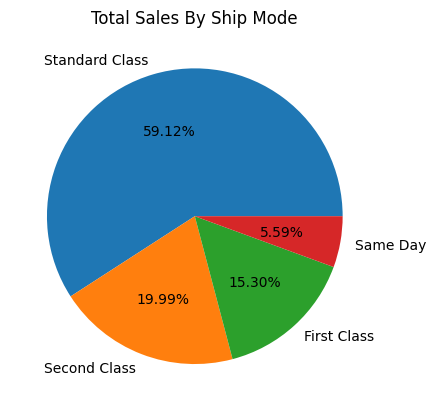

In [13]:
plt.figure()
shipmode_sales.plot(
    kind="pie",
    autopct='%1.2f%%'
    )
plt.title("Total Sales By Ship Mode")
plt.ylabel("")
#plt.xlabel("Ship Mode")
#plt.grid()
plt.show()

In [14]:
shipmode_profit = df.groupby("Ship Mode")["Profit"].sum()
shipmode_profit = shipmode_profit.sort_values(ascending=False)

print(f"Ship Mode Sales according to their class \n{shipmode_profit}")

Ship Mode Sales according to their class 
Ship Mode
Standard Class    164088.7875
Second Class       57446.6354
First Class        48969.8399
Same Day           15891.7589
Name: Profit, dtype: float64


In [15]:
#combine into one DataFrame
shipmode_summary = pd.DataFrame({
    "Sales": shipmode_sales,
    "Profit": shipmode_profit
})

print(shipmode_summary)

                       Sales       Profit
Ship Mode                                
Standard Class  1.358216e+06  164088.7875
Second Class    4.591936e+05   57446.6354
First Class     3.514284e+05   48969.8399
Same Day        1.283631e+05   15891.7589


<Figure size 640x480 with 0 Axes>

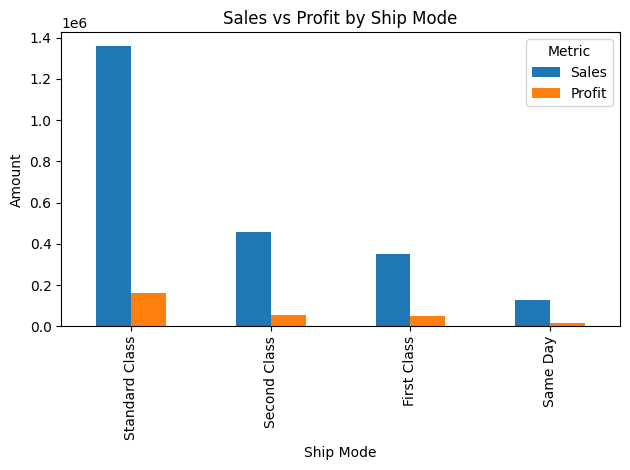

In [16]:
plt.figure()
shipmode_summary.plot(kind="bar")
plt.title("Sales vs Profit by Ship Mode")
plt.ylabel("Amount")
plt.xlabel("Ship Mode")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

Calculate Profit Margine by Ship Mode

In [17]:
shipmode_margin = (shipmode_profit/ shipmode_sales) * 100
print(f"Ship Mode Profit Margine According to their Calss \n\n{shipmode_margin}")

Ship Mode Profit Margine According to their Calss 

Ship Mode
Standard Class    12.081202
Second Class      12.510331
First Class       13.934513
Same Day          12.380315
dtype: float64


In [18]:
shipmode_summary = pd.DataFrame({
    "Sales": shipmode_sales,
    "Profit": shipmode_profit,
    "Profit Margin (%)": shipmode_margin
})
print(shipmode_summary)

                       Sales       Profit  Profit Margin (%)
Ship Mode                                                   
Standard Class  1.358216e+06  164088.7875          12.081202
Second Class    4.591936e+05   57446.6354          12.510331
First Class     3.514284e+05   48969.8399          13.934513
Same Day        1.283631e+05   15891.7589          12.380315


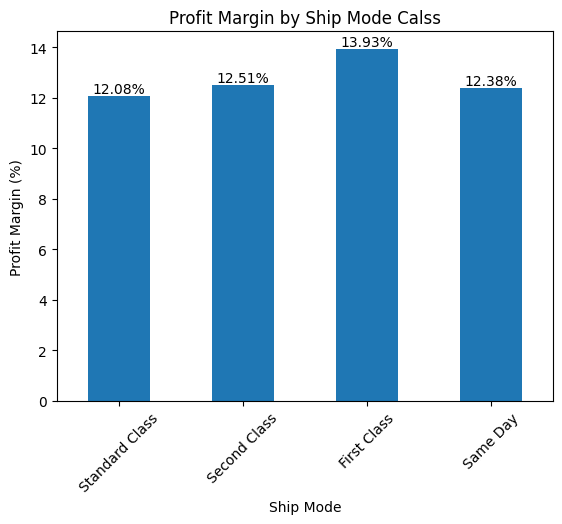

In [19]:
plt.figure()

shipmode_margin.plot(kind="bar")
plt.title("Profit Margin by Ship Mode Calss")
plt.ylabel("Profit Margin (%)")
plt.xlabel("Ship Mode")
plt.xticks(rotation=45)

for i, value in enumerate(shipmode_margin):
    plt.text(i, value, f"{value:.2f}%",
             ha='center',
             va='bottom')

plt.show()

Although The Standard Class generate the Highest Sales, But the highest Profit Margin come from First Class Ship Mode

So, It will be good for the company to advertise more for First Class Ship Mode wich can bring more profit for the Comapy & It will be better cost efficiency

In [20]:
region_ship_count = df.groupby(["Region", "Ship Mode"]).size().unstack()

region_ship_count

Ship Mode,First Class,Same Day,Second Class,Standard Class
Region,,,,
Central,299,120,465,1439
East,490,155,530,1673
South,234,83,329,974
West,515,185,621,1882


In [21]:

top_shipmode = region_ship_count.idxmax(axis=1)
print(f"Most used Ship Mode in each Region\n")
top_shipmode

Most used Ship Mode in each Region



Region
Central    Standard Class
East       Standard Class
South      Standard Class
West       Standard Class
dtype: str

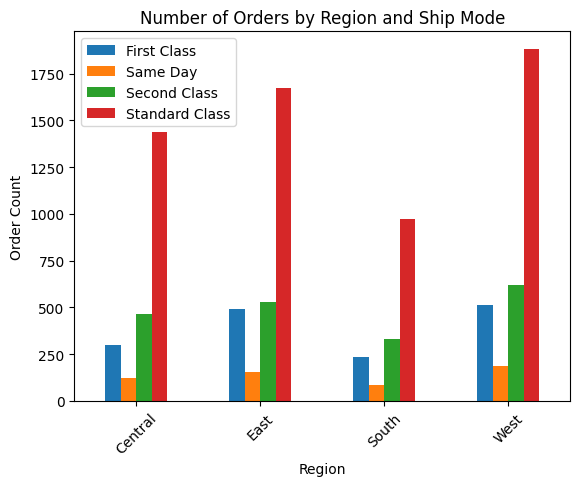

In [22]:
region_ship_count.plot(kind="bar")
plt.title("Number of Orders by Region and Ship Mode")
plt.ylabel("Order Count")
plt.xlabel("Region")
plt.legend()
plt.xticks(rotation=45)
plt.show()

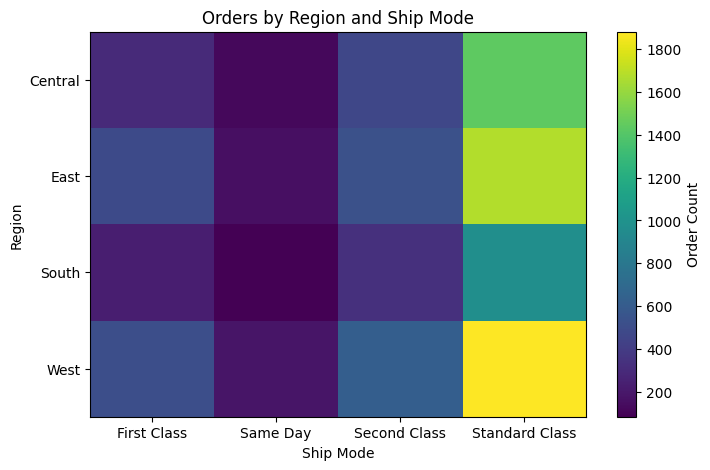

In [23]:
plt. figure(figsize=(8,5))
plt.imshow(region_ship_count, aspect='auto')
plt.colorbar(label="Order Count")
plt.xticks(range(len(region_ship_count.columns)), region_ship_count.columns)
plt.yticks(range(len(region_ship_count.index)), region_ship_count.index)
plt.title("Orders by Region and Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Region")
plt.show()

## The analysis shows that Standard Class shipping has the highest numbers of orders across most regions, indicating that customers prefer economical shipping options over faster delivery modes

In [24]:
city_sales = df.groupby("City")["Sales"].sum()
print(city_sales)

City
Aberdeen         25.500
Abilene           1.392
Akron          2729.986
Albuquerque    2220.160
Alexandria     5519.570
                 ...   
Woonsocket      195.550
Yonkers        7657.666
York            817.978
Yucaipa          50.800
Yuma            840.865
Name: Sales, Length: 531, dtype: float64


In [25]:
city_sales = city_sales.sort_values(ascending=False)

print(city_sales)

City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
                    ...    
Ormond Beach          2.808
Pensacola             2.214
Jupiter               2.064
Elyria                1.824
Abilene               1.392
Name: Sales, Length: 531, dtype: float64


In [26]:
t10_cities = city_sales.head(10)
print(f"Top Ten Cities \n\n{t10_cities}")

Top Ten Cities 

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


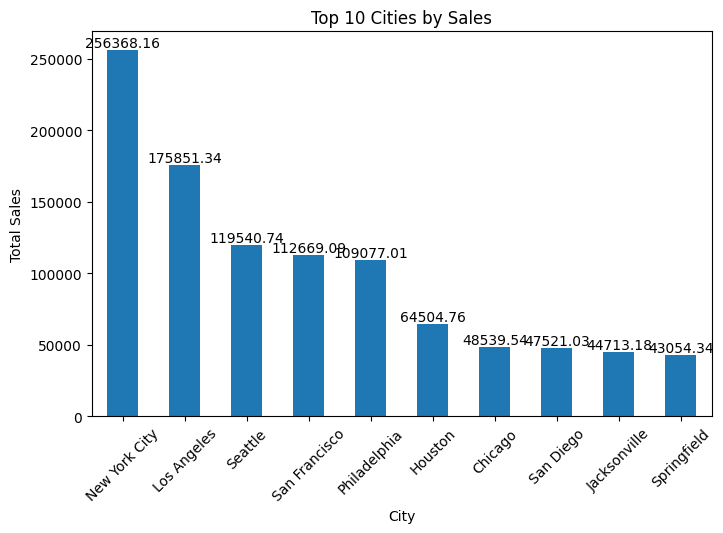

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = t10_cities.plot(kind="bar")
for i, value in enumerate(t10_cities):
    ax.text(i, value, f"{value:0.2f}", ha='center', va='bottom')

plt.title("Top 10 Cities by Sales")
plt.ylabel("Total Sales")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

## The Anlysis shows that New York City and Los Angeles generate the highest sales, and that indicate strong demand in large metropolitan areas.

# Profit Margin VS Discount 

In [28]:
df["Profit Margin (%)"] = (df["Profit"]/df["Sales"]) * 100
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%)
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028,16.25
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332,17.00
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932,7.50
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200,45.00


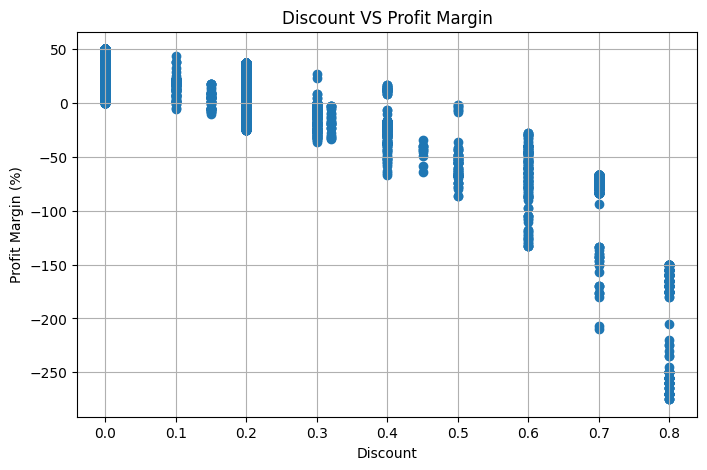

In [29]:
import matplotlib.pyplot as plt
plt. figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit Margin (%)"])
plt.title("Discount VS Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.grid()
plt.show()

## Profit Margin decreases as discount increas
### That's mean, Discounts reduce the profitability
## In the Scatter Plot, many points are bellow zero
### Which means company is losing money

## From the Scatter Plot we can say that company is losing money most of the cases, and it can be prevent by giving low discount to make High Margin of the product 

In [30]:
df[["Discount", "Profit Margin (%)"]].corr()

,Discount,Profit Margin (%)
Discount,1.000000,-0.864452
Profit Margin (%),-0.864452,1.000000


# Here, the Correlation value is Negetive of the Profit Margin 
## Which also indicates, as the discount increase, the profit margin decreases

In [31]:
discount_margin = df.groupby("Discount")["Profit Margin (%)"].mean()
print(discount_margin)

Discount
0.00     34.016048
0.10     15.579196
0.15      3.416290
0.20     17.683894
0.30    -11.548143
0.32    -17.429194
0.40    -22.249191
0.45    -45.454545
0.50    -54.909091
0.60    -68.913043
0.70    -79.473684
0.80   -182.500000
Name: Profit Margin (%), dtype: float64


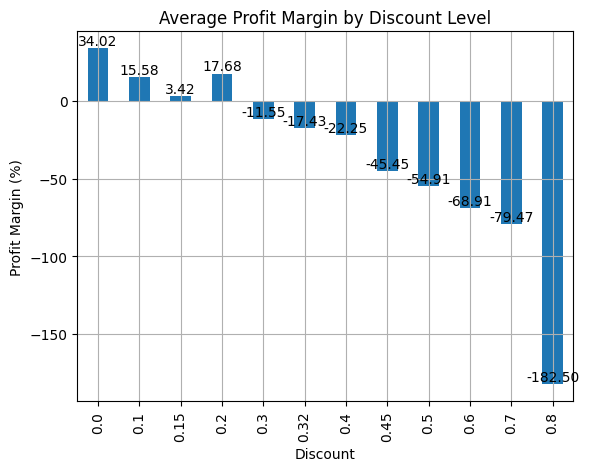

In [32]:
dm = discount_margin.plot(kind="bar")
for i, value in enumerate(discount_margin):
    dm.text(i, value, f"{value:0.2f}", ha="center", va="bottom")

plt.title("Average Profit Margin by Discount Level")
plt.ylabel("Profit Margin (%)")
plt.xlabel("Discount")
plt.grid()
plt.show()

The analysis shows that higher discount levels are associeted with lower profit margins. This indicates that aggressive discounting may reduce profitability and should be carefully managed.

### In this dataset, you wil likely see that high discounts often lead to negative profit margins, which  means the company is selling at a loss.